<a href="https://colab.research.google.com/github/Jayalekshmi872/AI-ML_ICTK/blob/main/Project_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout

In [73]:
df = pd.read_csv("/content/judge-1377884607_tweet_product_company.csv", encoding='latin1')

In [74]:
df

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",iPhone,Negative emotion
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,iPad or iPhone App,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",Google,Positive emotion
...,...,...,...
9088,Ipad everywhere. #SXSW {link},iPad,Positive emotion
9089,"Wave, buzz... RT @mention We interrupt your regularly scheduled #sxsw geek programming with big news {link} #google #circles",NaN,No emotion toward brand or product
9090,"Google's Zeiger, a physician never reported potential AE. Yet FDA relies on physicians. &quot;We're operating w/out data.&quot; #sxsw #health2dev",NaN,No emotion toward brand or product
9091,Some Verizon iPhone customers complained their time fell back an hour this weekend. Of course they were the New Yorkers who attended #SXSW.,NaN,No emotion toward brand or product


In [75]:
df.shape

(9093, 3)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   tweet_text                                          9092 non-null   object
 1   emotion_in_tweet_is_directed_at                     3291 non-null   object
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   object
dtypes: object(3)
memory usage: 213.2+ KB


In [77]:
df.isnull().sum()

,0
tweet_text,1
emotion_in_tweet_is_directed_at,5802
is_there_an_emotion_directed_at_a_brand_or_product,0


In [78]:
df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts()

,count
is_there_an_emotion_directed_at_a_brand_or_product,
No emotion toward brand or product,5389
Positive emotion,2978
Negative emotion,570
I can't tell,156


In [79]:
df.drop(columns='emotion_in_tweet_is_directed_at',inplace=True)

In [80]:
df.duplicated().sum()

np.int64(22)

In [81]:
df.drop_duplicates(inplace=True)

In [82]:
df.describe(include='all')

,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product
count,9070,9071
unique,9065,4
top,RT @mention RT @mention It's not a rumor: Apple is opening up a temporary store in downtown Austin for #SXSW and the iPad 2 launch {link},No emotion toward brand or product
freq,2,5376


In [83]:
df.isnull().sum()

,0
tweet_text,1
is_there_an_emotion_directed_at_a_brand_or_product,0


In [84]:
df[df['tweet_text'].isnull()]

,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product
6,NaN,No emotion toward brand or product


In [85]:
df.dropna(inplace=True)

In [86]:
df

,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",Negative emotion
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,Positive emotion
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,Negative emotion
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",Positive emotion
...,...,...
9088,Ipad everywhere. #SXSW {link},Positive emotion
9089,"Wave, buzz... RT @mention We interrupt your regularly scheduled #sxsw geek programming with big news {link} #google #circles",No emotion toward brand or product
9090,"Google's Zeiger, a physician never reported potential AE. Yet FDA relies on physicians. &quot;We're operating w/out data.&quot; #sxsw #health2dev",No emotion toward brand or product
9091,Some Verizon iPhone customers complained their time fell back an hour this weekend. Of course they were the New Yorkers who attended #SXSW.,No emotion toward brand or product


In [87]:
df.isna().sum()

,0
tweet_text,0
is_there_an_emotion_directed_at_a_brand_or_product,0


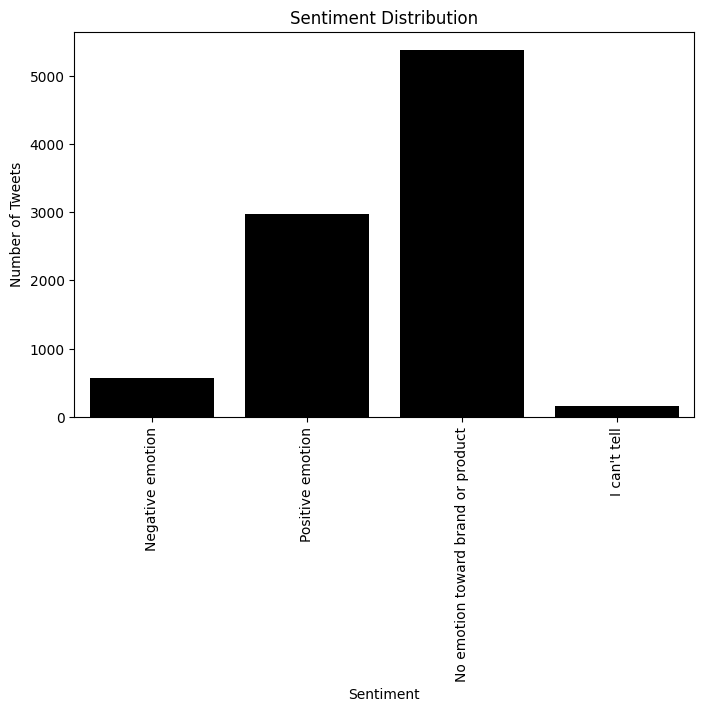

In [88]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='is_there_an_emotion_directed_at_a_brand_or_product',color='k')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.xticks(rotation=90)
plt.ylabel('Number of Tweets')

plt.show()

###Data Cleaning

In [89]:
import re

In [90]:
#Text Preprocessing
import string

def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags symbol
    text = re.sub(r'#', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [91]:
df['clean_text'] = df['tweet_text'].apply(clean_text)

In [92]:
df[['tweet_text', 'clean_text']].head(10)

,tweet_text,clean_text
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",i have a 3g iphone after 3 hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,can not wait for ipad 2 also they should sale them down at sxsw
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,i hope this years festival isnt as crashy as this years iphone app sxsw
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress
5,@teachntech00 New iPad Apps For #SpeechTherapy And Communication Are Showcased At The #SXSW Conference http://ht.ly/49n4M #iear #edchat #asd,new ipad apps for speechtherapy and communication are showcased at the sxsw conference iear edchat asd
7,"#SXSW is just starting, #CTIA is around the corner and #googleio is only a hop skip and a jump from there, good time to be an #android fan",sxsw is just starting ctia is around the corner and googleio is only a hop skip and a jump from there good time to be an android fan
8,Beautifully smart and simple idea RT @madebymany @thenextweb wrote about our #hollergram iPad app for #sxsw! http://bit.ly/ieaVOB,beautifully smart and simple idea rt wrote about our hollergram ipad app for sxsw
9,Counting down the days to #sxsw plus strong Canadian dollar means stock up on Apple gear,counting down the days to sxsw plus strong canadian dollar means stock up on apple gear
10,Excited to meet the @samsungmobileus at #sxsw so I can show them my Sprint Galaxy S still running Android 2.1. #fail,excited to meet the at sxsw so i can show them my sprint galaxy s still running android 21 fail


In [93]:
df

,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product,clean_text
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",Negative emotion,i have a 3g iphone after 3 hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",Positive emotion,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,Positive emotion,can not wait for ipad 2 also they should sale them down at sxsw
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,Negative emotion,i hope this years festival isnt as crashy as this years iphone app sxsw
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",Positive emotion,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress
...,...,...,...
9088,Ipad everywhere. #SXSW {link},Positive emotion,ipad everywhere sxsw link
9089,"Wave, buzz... RT @mention We interrupt your regularly scheduled #sxsw geek programming with big news {link} #google #circles",No emotion toward brand or product,wave buzz rt we interrupt your regularly scheduled sxsw geek programming with big news link google circles
9090,"Google's Zeiger, a physician never reported potential AE. Yet FDA relies on physicians. &quot;We're operating w/out data.&quot; #sxsw #health2dev",No emotion toward brand or product,googles zeiger a physician never reported potential ae yet fda relies on physicians quotwere operating wout dataquot sxsw health2dev
9091,Some Verizon iPhone customers complained their time fell back an hour this weekend. Of course they were the New Yorkers who attended #SXSW.,No emotion toward brand or product,some verizon iphone customers complained their time fell back an hour this weekend of course they were the new yorkers who attended sxsw


In [94]:
df['clean_text'].isnull().sum()

np.int64(0)

In [95]:
df[['clean_text', 'is_there_an_emotion_directed_at_a_brand_or_product']].head(20)

,clean_text,is_there_an_emotion_directed_at_a_brand_or_product
0,i have a 3g iphone after 3 hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw,Negative emotion
1,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw,Positive emotion
2,can not wait for ipad 2 also they should sale them down at sxsw,Positive emotion
3,i hope this years festival isnt as crashy as this years iphone app sxsw,Negative emotion
4,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress,Positive emotion
5,new ipad apps for speechtherapy and communication are showcased at the sxsw conference iear edchat asd,No emotion toward brand or product
7,sxsw is just starting ctia is around the corner and googleio is only a hop skip and a jump from there good time to be an android fan,Positive emotion
8,beautifully smart and simple idea rt wrote about our hollergram ipad app for sxsw,Positive emotion
9,counting down the days to sxsw plus strong canadian dollar means stock up on apple gear,Positive emotion
10,excited to meet the at sxsw so i can show them my sprint galaxy s still running android 21 fail,Positive emotion


In [96]:
pd.set_option('display.max_colwidth', None)

df.head(10)

,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product,clean_text
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",Negative emotion,i have a 3g iphone after 3 hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",Positive emotion,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,Positive emotion,can not wait for ipad 2 also they should sale them down at sxsw
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,Negative emotion,i hope this years festival isnt as crashy as this years iphone app sxsw
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",Positive emotion,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress
5,@teachntech00 New iPad Apps For #SpeechTherapy And Communication Are Showcased At The #SXSW Conference http://ht.ly/49n4M #iear #edchat #asd,No emotion toward brand or product,new ipad apps for speechtherapy and communication are showcased at the sxsw conference iear edchat asd
7,"#SXSW is just starting, #CTIA is around the corner and #googleio is only a hop skip and a jump from there, good time to be an #android fan",Positive emotion,sxsw is just starting ctia is around the corner and googleio is only a hop skip and a jump from there good time to be an android fan
8,Beautifully smart and simple idea RT @madebymany @thenextweb wrote about our #hollergram iPad app for #sxsw! http://bit.ly/ieaVOB,Positive emotion,beautifully smart and simple idea rt wrote about our hollergram ipad app for sxsw
9,Counting down the days to #sxsw plus strong Canadian dollar means stock up on Apple gear,Positive emotion,counting down the days to sxsw plus strong canadian dollar means stock up on apple gear
10,Excited to meet the @samsungmobileus at #sxsw so I can show them my Sprint Galaxy S still running Android 2.1. #fail,Positive emotion,excited to meet the at sxsw so i can show them my sprint galaxy s still running android 21 fail


In [97]:
pd.set_option('display.max_colwidth', None)

df.iloc[:10]

,tweet_text,is_there_an_emotion_directed_at_a_brand_or_product,clean_text
0,".@wesley83 I have a 3G iPhone. After 3 hrs tweeting at #RISE_Austin, it was dead! I need to upgrade. Plugin stations at #SXSW.",Negative emotion,i have a 3g iphone after 3 hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw
1,"@jessedee Know about @fludapp ? Awesome iPad/iPhone app that you'll likely appreciate for its design. Also, they're giving free Ts at #SXSW",Positive emotion,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw
2,@swonderlin Can not wait for #iPad 2 also. They should sale them down at #SXSW.,Positive emotion,can not wait for ipad 2 also they should sale them down at sxsw
3,@sxsw I hope this year's festival isn't as crashy as this year's iPhone app. #sxsw,Negative emotion,i hope this years festival isnt as crashy as this years iphone app sxsw
4,"@sxtxstate great stuff on Fri #SXSW: Marissa Mayer (Google), Tim O'Reilly (tech books/conferences) &amp; Matt Mullenweg (Wordpress)",Positive emotion,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress
5,@teachntech00 New iPad Apps For #SpeechTherapy And Communication Are Showcased At The #SXSW Conference http://ht.ly/49n4M #iear #edchat #asd,No emotion toward brand or product,new ipad apps for speechtherapy and communication are showcased at the sxsw conference iear edchat asd
7,"#SXSW is just starting, #CTIA is around the corner and #googleio is only a hop skip and a jump from there, good time to be an #android fan",Positive emotion,sxsw is just starting ctia is around the corner and googleio is only a hop skip and a jump from there good time to be an android fan
8,Beautifully smart and simple idea RT @madebymany @thenextweb wrote about our #hollergram iPad app for #sxsw! http://bit.ly/ieaVOB,Positive emotion,beautifully smart and simple idea rt wrote about our hollergram ipad app for sxsw
9,Counting down the days to #sxsw plus strong Canadian dollar means stock up on Apple gear,Positive emotion,counting down the days to sxsw plus strong canadian dollar means stock up on apple gear
10,Excited to meet the @samsungmobileus at #sxsw so I can show them my Sprint Galaxy S still running Android 2.1. #fail,Positive emotion,excited to meet the at sxsw so i can show them my sprint galaxy s still running android 21 fail


In [98]:
X = df['clean_text']
y = df['is_there_an_emotion_directed_at_a_brand_or_product']


In [99]:
X.head()

,clean_text
0,i have a 3g iphone after 3 hrs tweeting at riseaustin it was dead i need to upgrade plugin stations at sxsw
1,know about awesome ipadiphone app that youll likely appreciate for its design also theyre giving free ts at sxsw
2,can not wait for ipad 2 also they should sale them down at sxsw
3,i hope this years festival isnt as crashy as this years iphone app sxsw
4,great stuff on fri sxsw marissa mayer google tim oreilly tech booksconferences amp matt mullenweg wordpress


In [100]:
y.head()

,is_there_an_emotion_directed_at_a_brand_or_product
0,Negative emotion
1,Positive emotion
2,Positive emotion
3,Negative emotion
4,Positive emotion


In [101]:
le=LabelEncoder()
y=le.fit_transform(y)

In [102]:
le.classes_

array(["I can't tell", 'Negative emotion',
       'No emotion toward brand or product', 'Positive emotion'],
      dtype=object)

In [103]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3]), array([ 156,  569, 5375, 2970]))

In [104]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [105]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7256
Testing samples: 1814


### Step 11: Tokenization

In [106]:
#Tokenization
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [107]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [108]:
X_train_seq[:3]

[[828, 28, 17, 16, 9, 221, 1465, 16, 5221, 5222, 2, 5223, 489, 828, 1205, 4],
 [86, 264, 15, 254, 388, 16, 180, 1334, 14, 407, 26, 3, 12, 18, 2, 12],
 [3458, 3459, 6, 2, 3460, 57, 39, 693, 14, 11, 590, 959, 309, 11, 3461, 1466]]

### Padding Sequences

In [109]:
max_length = 50
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [110]:
X_train_pad.shape

(7256, 50)

In [111]:
X_test_pad.shape

(1814, 50)

In [112]:
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

print("Vocabulary size:", vocab_size)

Vocabulary size: 9851


### Building the LSTM Model

In [113]:
model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dropout(0.3),

    Dense(4, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [114]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [115]:
#Compiling the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [116]:
from tensorflow.keras.callbacks import EarlyStopping

In [117]:
#Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [118]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights

array([14.512     ,  3.98681319,  0.42186047,  0.76346801])

In [119]:
class_weight_dict = dict(
    zip(classes, class_weights)
)

class_weight_dict

{np.int64(0): np.float64(14.512),
 np.int64(1): np.float64(3.986813186813187),
 np.int64(2): np.float64(0.42186046511627906),
 np.int64(3): np.float64(0.7634680134680135)}

In [120]:
#Training the LSTM Model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    #class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.5405 - loss: 1.0152 - val_accuracy: 0.6095 - val_loss: 0.8980
Epoch 2/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.5753 - loss: 0.9589 - val_accuracy: 0.6095 - val_loss: 0.8894
Epoch 3/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.5805 - loss: 0.9539 - val_accuracy: 0.6095 - val_loss: 0.8927
Epoch 4/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.5843 - loss: 0.9494 - val_accuracy: 0.6095 - val_loss: 0.9070
Epoch 5/20
182/182 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.5882 - loss: 0.9439 - val_accuracy: 0.6095 - val_loss: 0.8990


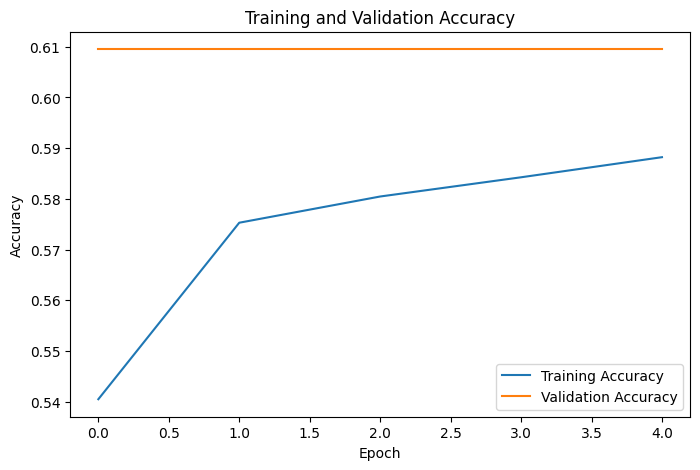

In [121]:
#Training and Validation Accuracy
#plot accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

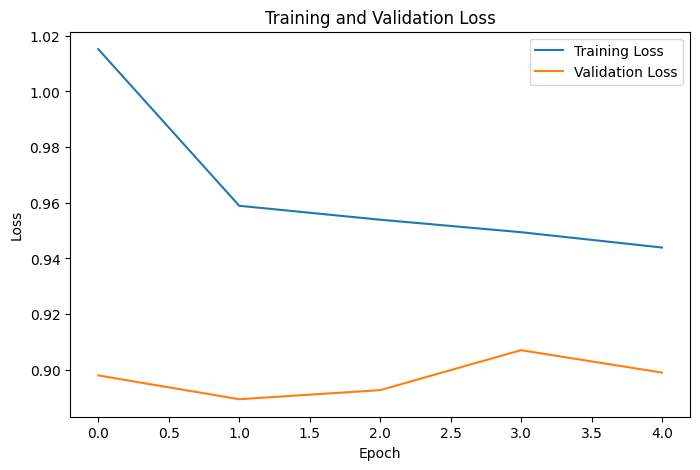

In [122]:
#plot loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [123]:
#Model Evaluation
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5926 - loss: 0.9192


In [124]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.9192450642585754
Test Accuracy: 0.5926129817962646


In [125]:
y_pred_prob = model.predict(X_test_pad)


57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [126]:
y_pred = np.argmax(y_pred_prob, axis=1)


In [127]:
y_pred

array([2, 2, 2, ..., 2, 2, 2])

In [128]:
from sklearn.metrics import classification_report,confusion_matrix
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

                                    precision    recall  f1-score   support

                      I can't tell       0.00      0.00      0.00        31
                  Negative emotion       0.00      0.00      0.00       114
No emotion toward brand or product       0.59      1.00      0.74      1075
                  Positive emotion       0.00      0.00      0.00       594

                          accuracy                           0.59      1814
                         macro avg       0.15      0.25      0.19      1814
                      weighted avg       0.35      0.59      0.44      1814



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


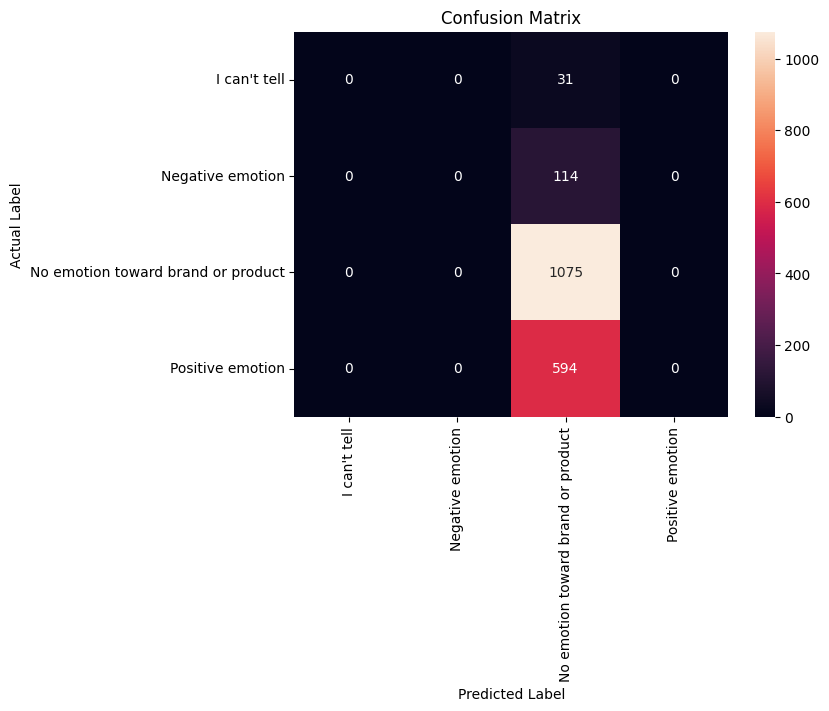

In [129]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')

plt.show()

In [130]:
#Testing the Model with New Tweets
new_tweets = [
    "I absolutely love the new Apple product",
    "This Google product is terrible and disappointing",
    "The product was launched today",
    "I don't know what to think about this product"
]

In [131]:
new_tweets_clean = [clean_text(tweet) for tweet in new_tweets]

In [132]:
new_tweets_seq = tokenizer.texts_to_sequences(new_tweets_clean)

In [133]:
new_tweets_pad = pad_sequences(
    new_tweets_seq,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

In [134]:
predictions = model.predict(new_tweets_pad)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [135]:
predicted_classes = np.argmax(predictions, axis=1)

In [136]:
predicted_sentiments = le.inverse_transform(
    predicted_classes
)

In [137]:
for tweet, sentiment in zip(new_tweets, predicted_sentiments):
    print("Tweet:", tweet)
    print("Predicted Sentiment:", sentiment)
    print("-" * 50)

Tweet: I absolutely love the new Apple product
Predicted Sentiment: No emotion toward brand or product
--------------------------------------------------
Tweet: This Google product is terrible and disappointing
Predicted Sentiment: No emotion toward brand or product
--------------------------------------------------
Tweet: The product was launched today
Predicted Sentiment: No emotion toward brand or product
--------------------------------------------------
Tweet: I don't know what to think about this product
Predicted Sentiment: No emotion toward brand or product
--------------------------------------------------


In [138]:
#Saving the Trained Model
model.save('twitter_sentiment_lstm.keras')

In [139]:
import pickle

with open('tokenizer.pkl', 'wb') as file:
    pickle.dump(tokenizer, file)

In [140]:
#conclusion

* We performed NLP preprocessing on Twitter data.

* Tweets were tokenized and padded.

* An LSTM-based Deep Learning model was built.

* The model classified tweets into four sentiment classes.

* The model was evaluated using accuracy, classification report and confusion matrix.

* New tweets were also tested using the trained model.